In [4]:
import sys
import os

import xarray as xr
import rioxarray
import sys
sys.path.insert(1, '../Tools/')
import argparse 
import os
import sys
import xarray as xr
import mypythonlib
from mypythonlib import myfunctions 
import geopandas as gpd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
from shapely.geometry import mapping
import warnings
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
from matplotlib.ticker import MaxNLocator, FuncFormatter
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import shape, MultiPolygon, box
from affine import Affine
import rasterio
from shapely import wkt

# S1 Change-Detection-Tile Processing Pipeline

Description: This code processes a dataset through several steps including loading, cleaning, renaming, and reprojecting.

1. Load dataset with filename

2. Define the Coordinate Reference Systems (CRS) for the azimuthal equidistant and WGS 84 projections.

3. Define the variables to drop

4. Drop 'x_bnds' and 'y_bnds' if they exist in the dataset

5. Update the list of variables after dropping

6. Rename 'unnamed' variable to 'layer' if it exists

7. Rename 'X' and 'Y' variables to 'x' and 'y' if both exist

8. Update the list of variables after renaming

9. Write the azimuthal equidistant CRS to the dataset

10. Reproject the dataset to the WGS 84 projection (EPSG:4326)

In [5]:
# Define variables for dynamic data directory construction
input_file = "/Net/Groups/BGI/work_2/ForExD/WP1/Data/s1_change_detection_northamerica/EQUI7_NA020M_E084N024T3_rqatrend_VH_A_thresh_3.0_year_2016_cluster_compressed.nc"
filename = os.path.basename(input_file)
print("Filename:", filename)

Filename: EQUI7_NA020M_E084N024T3_rqatrend_VH_A_thresh_3.0_year_2016_cluster_compressed.nc


In [6]:
def extract_filename_part(filename):
    # Split the filename by underscores
    parts = filename.split('_')
    
    # Join the parts up to and including the year
    # Assumes the year is always the 8th part of the filename
    extracted_part = '_'.join(parts[0:10])
    
    return extracted_part

# Example usage
input_file = "EQUI7_NA020M_E084N024T3_rqatrend_VH_A_thresh_3.0_year_2016_cluster_compressed.nc"
extracted_part = extract_filename_part(os.path.basename(input_file))
print(extracted_part)

EQUI7_NA020M_E084N024T3_rqatrend_VH_A_thresh_3.0_year_2016


In [7]:
import os

# Define variables for dynamic data directory construction
input_file = "/Net/Groups/BGI/work_2/ForExD/WP1/Data/s1_change_detection_northamerica/EQUI7_NA020M_E084N024T3_rqatrend_VH_A_thresh_3.0_year_2016_cluster_compressed.nc"
filename = os.path.basename(input_file)
print("Filename:", filename)

# Step 1: Load dataset with filename
print("Step  1: Load data from:", filename)
filename = os.path.basename(input_file)
dataset = xr.open_dataset(input_file)
print("     Dataset loaded successfully.")
# Get a list of variable names in the dataset
variables = list(dataset.variables)
print("     Variables in the dataset:", variables)

# Step 2: Define the Coordinate Reference Systems (CRS)
print("Step 2: Define the Coordinate Reference Systems (CRS)")
crs_azimuthal_equidistant = "+proj=aeqd +lat_0=52 +lon_0=-97.5 +x_0=8264722.17686 +y_0=4867518.35323 +datum=WGS84 +units=m +no_defs"
crs_wgs84 = 'GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]]'


# Step 3: Define the variables to drop
print("Step 3: Define the variables to drop")
variables_to_remove = ["x_bnds", "y_bnds"]

# Step 4: Drop 'x_bnds' and 'y_bnds' if they exist in the dataset
print("Step 4: Drop 'x_bnds' and 'y_bnds' if they exist in the dataset")
for variable in variables_to_remove:
    if variable in dataset.variables:
        dataset = dataset.drop_vars(variable)
print("     Variables 'x_bnds' and 'y_bnds' dropped successfully.")

# Step 5: Update the list of variables after dropping
print("Step 5: Update the list of variables after dropping")
current_variable_list = list(dataset.variables)

# Step 6: Rename 'unnamed' variable to 'layer' if it exists
print("Step 6: Rename 'unnamed' variable to 'layer' if it exists")
if 'unnamed' in dataset.variables:
    dataset = dataset.rename({'unnamed': 'layer'})
    print("     Variable 'unnamed' renamed to 'layer'.")
else:
    print("     No variable named 'unnamed' found.")

# Step 7: Rename 'X' and 'Y' variables to 'x' and 'y' if both exist
print("Step 7: Rename 'X' and 'Y' variables to 'x' and 'y' if both exist")
if 'X' in dataset.variables and 'Y' in dataset.variables:
    dataset = dataset.rename({'X': 'x', 'Y': 'y'})
    print("     Variables 'X' and 'Y' renamed to 'x' and 'y'.")
else:
    print("     No variables named 'X' and 'Y' found.")

# Step 8: Update the list of variables after renaming
print("Step 8: Update the list of variables after renaming")
current_variable_list = list(dataset.variables)
print("     Current variables:", current_variable_list)

# Step 9: Write the azimuthal equidistant CRS to the dataset
print("Step 9: Write the azimuthal equidistant CRS to the dataset")
dataset.rio.write_crs(crs_azimuthal_equidistant, inplace=True)

# Step 10: Reproject the dataset to the WGS 84 projection (EPSG:4326)
print("Step 10: Reproject the dataset to the WGS 84 projection (EPSG:4326)")
dataset_wgs84 = dataset.rio.reproject(crs_wgs84)

dataset_wgs84

Filename: EQUI7_NA020M_E084N024T3_rqatrend_VH_A_thresh_3.0_year_2016_cluster_compressed.nc
Step  1: Load data from: EQUI7_NA020M_E084N024T3_rqatrend_VH_A_thresh_3.0_year_2016_cluster_compressed.nc
     Dataset loaded successfully.
     Variables in the dataset: ['x_bnds', 'x', 'y_bnds', 'y', 'unnamed']
Step 2: Define the Coordinate Reference Systems (CRS)
Step 3: Define the variables to drop
Step 4: Drop 'x_bnds' and 'y_bnds' if they exist in the dataset
     Variables 'x_bnds' and 'y_bnds' dropped successfully.
Step 5: Update the list of variables after dropping
Step 6: Rename 'unnamed' variable to 'layer' if it exists
     Variable 'unnamed' renamed to 'layer'.
Step 7: Rename 'X' and 'Y' variables to 'x' and 'y' if both exist
     No variables named 'X' and 'Y' found.
Step 8: Update the list of variables after renaming
     Current variables: ['x', 'y', 'layer']
Step 9: Write the azimuthal equidistant CRS to the dataset
Step 10: Reproject the dataset to the WGS 84 projection (EPSG:43

<xarray.Dataset>
Dimensions:      (x: 16477, y: 14544)
Coordinates:
  * x            (x) float64 -96.14 -96.14 -96.14 ... -92.96 -92.96 -92.96
  * y            (y) float64 32.48 32.48 32.48 32.48 ... 29.68 29.68 29.67 29.67
    spatial_ref  int64 0
Data variables:
    layer        (y, x) float32 nan nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    _FillValue:  9.96921e+36

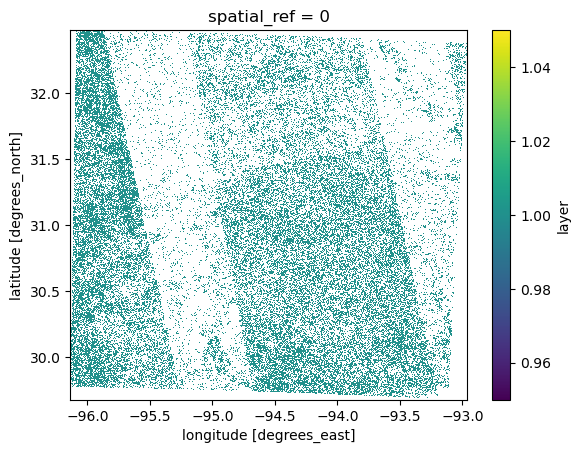

In [10]:
dataset_wgs84['layer'].plot()

# Apply TreeCanopyCover Map 2017

In [8]:
import xarray as xr
import rioxarray

# Step 1: Defining the NetCDF file
print("Step 1: Defining the NetCDF file...")
spatial_extent = dataset_wgs84

# Step 2: Define the path to the TIF file
print("Step 2: Defining the path to the TIF file...")
TCC_path_2017 = "/Net/Groups/BGI/work_2/ForExD/WP1/Data/NLCD_TCC_version_2021.4/nlcd_tcc_conus_2017_v2021-4/wp1_nlcd_tcc_conus_2017_v2021_4_20m_4326_cropped_region_08.tif"

# Step 3: Open the entire TIF file
print("Step 3: Opening the entire TIF file...")
tcc_2017 = rioxarray.open_rasterio(TCC_path_2017, decode_coords="all", masked=True)

# Step 4: Extract the spatial extent from the NetCDF file
print("Step 4: Extracting spatial extent from the NetCDF file...")
min_lon, max_lon = spatial_extent['x'].min(), spatial_extent['x'].max()
min_lat, max_lat = spatial_extent['y'].min(), spatial_extent['y'].max()

# Step 5: Select the subset using xarray's indexing capabilities
print("Step 5: Selecting the subset using xarray's indexing capabilities...")
subset = tcc_2017.sel(x=slice(min_lon, max_lon), y=slice(max_lat, min_lat))

# Step 6: Calculate the minimum value of the subset
print("Step 6: Calculating the minimum value of the subset...")
min_value = subset.min() if not subset.isnull().all() else 0

# Step 7: Calculate the normalized subset
print("Step 7: Calculating the normalized subset...")
normalized_subset = (subset - min_value) / (subset.max() - min_value) if subset.max() != min_value else subset

# Step 8: Set values equal to 1 to 0
print("Step 8: Setting values equal to 1 to 0...")
#normalized_subset = normalized_subset.where(normalized_subset != 1, 0)

# Step 9: Reindex the normalized subset to match the coordinates of dataset_wgs84
print("Step 9: Reindexing the normalized subset...")
normalized_subset = normalized_subset.reindex(x=spatial_extent.coords['x'], method='nearest')
normalized_subset = normalized_subset.reindex(y=spatial_extent.coords['y'], method='nearest')

# Step 10: Apply masking based on the normalized subset
print("Step 10: Applying masking based on the normalized subset...")
masked_mc = spatial_extent.where(normalized_subset > 0.3, 0).fillna(0)

masked_mc


Step 1: Defining the NetCDF file...
Step 2: Defining the path to the TIF file...
Step 3: Opening the entire TIF file...
Step 4: Extracting spatial extent from the NetCDF file...
Step 5: Selecting the subset using xarray's indexing capabilities...
Step 6: Calculating the minimum value of the subset...
Step 7: Calculating the normalized subset...
Step 8: Setting values equal to 1 to 0...
Step 9: Reindexing the normalized subset...
Step 10: Applying masking based on the normalized subset...


<xarray.Dataset>
Dimensions:      (y: 14544, x: 16477, band: 1)
Coordinates:
  * x            (x) float64 -96.14 -96.14 -96.14 ... -92.96 -92.96 -92.96
  * y            (y) float64 32.48 32.48 32.48 32.48 ... 29.68 29.68 29.67 29.67
    spatial_ref  int64 0
  * band         (band) int64 1
Data variables:
    layer        (y, x, band) float32 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    _FillValue:  9.96921e+36

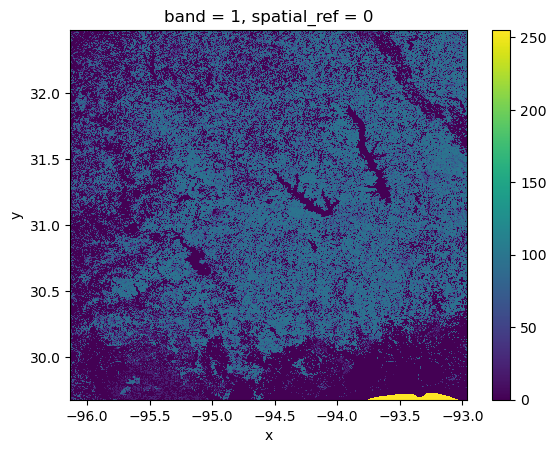

In [14]:
subset.plot()

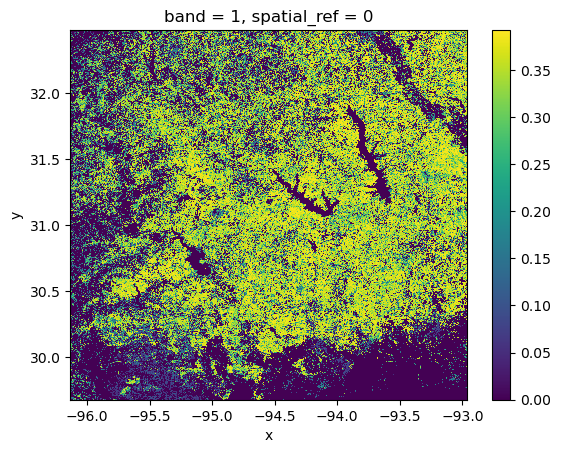

In [12]:
normalized_subset.plot()

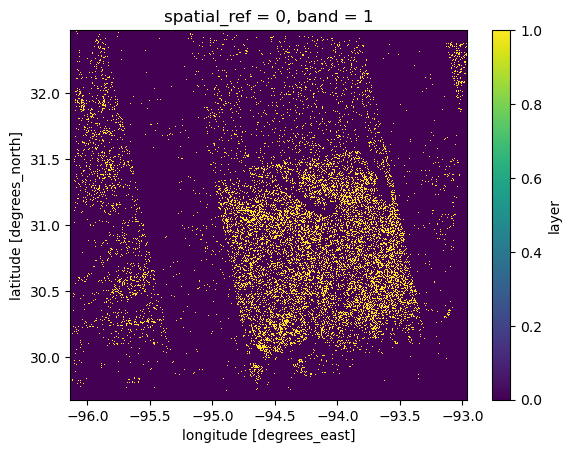

In [13]:
masked_mc.layer.plot()

# Extract Polygons

In [9]:
import geopandas as gpd
import numpy as np
import rasterio.features
from shapely.geometry import box, shape
from affine import Affine

def process_nc_file(filename, masked_mc):
    # Step 1: Extract the year and tile information from the file name
    print("Step 1: Extracting the year and tile information from the file name...")
    s1_year = int(filename.split('_year_')[-1].split('_')[0])
    tile_name = filename[13:23]
    print(f"    Processing year: {s1_year}")
    print(f"    Processing tile: {tile_name}")

    # Step 2: Initialize an empty GeoDataFrame to accumulate results
    print("Step 2: Initializing the GeoDataFrame to store results...")
    all_polygons_gdf = gpd.GeoDataFrame(columns=['geometry', 'S1_YEAR', 'S1_TILE'])

    # Step 3: Extract the bounds of the masked data array
    print("Step 3: Extracting the bounds of the masked data array...")
    min_lon, max_lon = masked_mc['x'].min().item(), masked_mc['x'].max().item()
    min_lat, max_lat = masked_mc['y'].min().item(), masked_mc['y'].max().item()

    # Step 4: Create a GeoDataFrame with the bounds of the masked data array
    print("Step 4: Creating a GeoDataFrame with the bounds of the masked data array...")
    bounds_gdf = gpd.GeoDataFrame(geometry=[box(min_lon, min_lat, max_lon, max_lat)])
    print(f"    Bounds: {min_lon}, {min_lat}, {max_lon}, {max_lat}")

    # Step 5: Drop the 'band' dimension from the masked data array
    print("Step 5: Dropping the 'band' dimension from the masked data array...")
    masked_mc_cropped = masked_mc.squeeze("band")

    # Step 6: Get the geospatial information from the data array
    print("Step 6: Extracting geospatial information from the data array...")
    transform = (Affine.translation(masked_mc_cropped.x[0], masked_mc_cropped.y[0]) * 
                    Affine.scale(masked_mc_cropped.x[1] - masked_mc_cropped.x[0], 
                                masked_mc_cropped.y[1] - masked_mc_cropped.y[0]))
    print(f"Affine transform: {transform}")

    # Step 7: Convert the cropped data into a mask with a valid data type
    print("Step 7: Converting the cropped data into a mask...")
    mask = (masked_mc_cropped['layer'] > 0).astype(np.uint8)

    # Step 8: Extract geometry shapes from the mask
    print("Step 8: Extracting shapes from the mask...")
    shapes = list(rasterio.features.shapes(mask, transform=transform))
    print(f"    Extracted {len(shapes)} shapes.")

    # Step 9: Create a list to store individual polygons
    print("Step 9: Creating individual polygons...")
    polygons_list = [shape(geom) for geom, value in shapes if value == 1]
    print(f"    Extracted {len(polygons_list)} polygons.")

    # Step 10: Create a GeoDataFrame from individual polygons
    print("Step 10: Creating a GeoDataFrame from individual polygons...")
    polygons_gdf = gpd.GeoDataFrame(geometry=polygons_list, crs=masked_mc_cropped.spatial_ref)

    # Step 11: Add columns with information from the current loop
    print("Step 11: Adding year and tile information to the GeoDataFrame...")
    polygons_gdf['S1_YEAR'] = s1_year
    polygons_gdf['S1_TILE'] = tile_name

    # Step 12: Append the GeoDataFrame to the result GeoDataFrame
    print("Step 12: Appending the current GeoDataFrame to the results...")
    all_polygons_gdf = all_polygons_gdf.append(polygons_gdf, ignore_index=True)
    print("     Polygon extraction and GeoDataFrame update completed.")

    return all_polygons_gdf

# Example usage:
print("Starting the polygon extraction process...")
polygons_gdf = process_nc_file(filename, masked_mc)
s1_year = int(filename.split('_year_')[-1].split('_')[0])
print(s1_year)

Starting the polygon extraction process...
Step 1: Extracting the year and tile information from the file name...
    Processing year: 2016
    Processing tile: E084N024T3
Step 2: Initializing the GeoDataFrame to store results...
Step 3: Extracting the bounds of the masked data array...
Step 4: Creating a GeoDataFrame with the bounds of the masked data array...
    Bounds: -96.1357052966501, 29.674782642282164, -92.96213890402673, 32.476019353129566
Step 5: Dropping the 'band' dimension from the masked data array...
Step 6: Extracting geospatial information from the data array...
Affine transform: | 0.00, 0.00,-96.14|
| 0.00,-0.00, 32.48|
| 0.00, 0.00, 1.00|
Step 7: Converting the cropped data into a mask...
Step 8: Extracting shapes from the mask...
    Extracted 3170279 shapes.
Step 9: Creating individual polygons...
    Extracted 2470528 polygons.
Step 10: Creating a GeoDataFrame from individual polygons...
Step 11: Adding year and tile information to the GeoDataFrame...
Step 12: Ap

/tmp/ipykernel_1675834/1190212651.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_polygons_gdf = all_polygons_gdf.append(polygons_gdf, ignore_index=True)


     Polygon extraction and GeoDataFrame update completed.
2016


In [10]:
polygons_gdf

,geometry,S1_YEAR,S1_TILE
0,"POLYGON ((-96.03997 32.47525, -96.03940 32.475...",2016,E084N024T3
1,"POLYGON ((-96.01590 32.47486, -96.01590 32.474...",2016,E084N024T3
2,"POLYGON ((-96.02861 32.47467, -96.02861 32.474...",2016,E084N024T3
3,"POLYGON ((-96.01513 32.47448, -96.01513 32.474...",2016,E084N024T3
4,"POLYGON ((-96.01455 32.47448, -96.01455 32.474...",2016,E084N024T3
...,...,...,...
2470523,"POLYGON ((-93.19867 29.67998, -93.19867 29.679...",2016,E084N024T3
2470524,"POLYGON ((-93.19771 29.67998, -93.19771 29.679...",2016,E084N024T3
2470525,"POLYGON ((-93.19810 29.68229, -93.19790 29.682...",2016,E084N024T3
2470526,"POLYGON ((-93.19347 29.68133, -93.19289 29.681...",2016,E084N024T3


<Axes: >

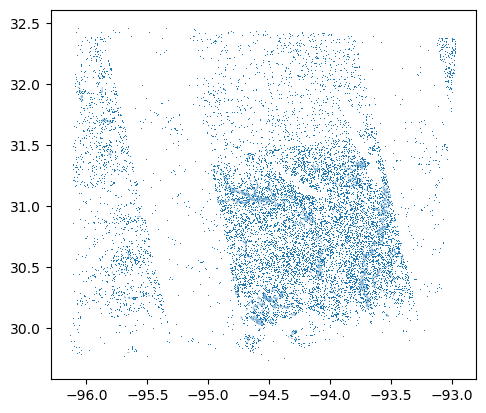

In [19]:
polygons_gdf.plot()

# Remove polygons not overlapping with IDS USDA

In [28]:
# Step 1: load the ids_usda file from path /Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/region8_dca_filtered_ids_usda_polygons.csv
# Step 2: add a buffer of 500m around the ids_usda geometries
# Step 3: Filter all elements from ids_usda, that are with a +-1 year buffer of the s1_year
# Step 4: Check where the polygon intersect with ids_usda keep just those that intersect with ids_usda

import geopandas as gpd
import pandas as pd

def process_and_filter_polygons(ids_usda_path, polygons_gdf, s1_year):
    # Step 1: Load the ids_usda file
    print("Step 1: Loading the ids_usda file...")
    ids_usda = pd.read_csv(ids_usda_path)
    # Step 2: Convert the WKT geometries to Shapely geometries
    print("     Converting WKT geometries...")
    ids_usda['geometry'] = ids_usda['geometry'].apply(wkt.loads)
    # Step 3: Convert the DataFrame to a GeoDataFrame
    print("     Converting DataFrame to GeoDataFrame...")
    ids_usda_gdf = gpd.GeoDataFrame(ids_usda, geometry='geometry')

    # Step 2: Add a buffer of 500m around the ids_usda geometries
    print("Step 2: Adding a 500m buffer around the ids_usda geometries...")
    ids_usda_gdf['geometry'] = ids_usda_gdf['geometry'].buffer(0.005)
    
    # Step 3: Filter elements from ids_usda within a +-1 year buffer of s1_year
    print(f"Step 3: Filtering ids_usda for elements within a +-1 year buffer of {s1_year}...")
    ids_usda_filtered = ids_usda_gdf[(ids_usda_gdf['SURVEY_YEAR'] >= s1_year - 1) & (ids_usda_gdf['SURVEY_YEAR'] <= s1_year + 1)]
    print(f"Filtered down from {len(ids_usda_gdf)} to {len(ids_usda_filtered)} entries within the 2 year buffer.")

     # Step 4: Spatially join polygons_gdf and ids_usda_filtered
    print("Step 4: Performing spatial join to find intersecting polygons...")
    intersecting_polygons_gdf = gpd.sjoin(polygons_gdf, ids_usda_filtered, predicate='intersects')
    intersecting_polygons_gdf = intersecting_polygons_gdf.rename(columns={'index_right': 'S1CD_INDEX', 'index_usda': 'USDA_INDEX'})
    print(f"Found {len(intersecting_polygons_gdf)}/{len(polygons_gdf)} intersecting polygons.")

    # Step 5: Rename columns to be less than or equal to 10 characters
    print("Step 5: Renaming columns to be less than or equal to 10 characters...")
    rename_mapping = {
        'SURVEY_YEAR': 'SURV_YEAR',
        'REGION_ID': 'REG_ID',
        'DAMAGE_TYPE': 'DAM_TYPE',
        'DAMAGE_TYPE_CODE': 'DAM_TYPE_CD',
        'DCA_CODE': 'DCA_CD',
        'DA_Code_USDA': 'DA_CD_USDA',
        'PERCENT_AFFECTED': 'PCT_AFFECT',
        'S1CD_INDEX': 'S1CD_IDX',
        'USDA_INDEX': 'USDA_IDX'
    }
    intersecting_polygons_gdf = intersecting_polygons_gdf.rename(columns=rename_mapping)
    
    # Step 6: Aggregating geometries based on their shared USDA_IDX
    print("Step 6: Aggregating geometries based on their shared USDA_IDX ...")
    merged_gdf = intersecting_polygons_gdf.dissolve(by='USDA_IDX')
    merged_gdf.reset_index(inplace=True)
    print(f"Total number of remaining rows: {len(merged_gdf)}/{len(intersecting_polygons_gdf)}")

    return merged_gdf

# Define the paths
ids_usda_path = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/region8_dca_filtered_ids_usda_polygons.csv"

print("Starting the filtering process...")
filtered_polygons_gdf = process_and_filter_polygons(ids_usda_path, polygons_gdf, s1_year)
print("Filtering and merging completed.")


Starting the filtering process...
Step 1: Loading the ids_usda file...
     Converting WKT geometries...
     Converting DataFrame to GeoDataFrame...
Step 2: Adding a 500m buffer around the ids_usda geometries...
Step 3: Filtering ids_usda for elements within a +-1 year buffer of 2016...
Filtered down from 10611 to 8057 entries within the 2 year buffer.
Step 4: Performing spatial join to find intersecting polygons...
Found 232/2470528 intersecting polygons.
Step 5: Renaming columns to be less than or equal to 10 characters...
Step 6: Aggregating geometries based on their shared USDA_IDX ...
Total number of rows: 14/232
Filtering and merging completed.


# Merge all Files to one big s1cd File

In [40]:
import os

# Define the folder path
folder_path = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/03_s1cd_polygons/"

# Get a list of all files in the folder
files_in_folder = os.listdir(folder_path)

# Count the number of files with the .shp extension
shp_file_count = sum(1 for file in files_in_folder if file.endswith('.shp'))

print(f"Number of .shp files in the folder: {shp_file_count}")


Number of .shp files in the folder: 100


In [2]:
import os
import glob
import shutil
import geopandas as gpd
import pandas as pd

def calculate_area(gdf):
    """Calculate area in square meters and square kilometers for a GeoDataFrame."""
    # Set the coordinate reference system (CRS) for the GeoDataFrame to WGS84
    gdf.crs = 'EPSG:4326'
    
    # Calculate the area in degrees (not used for final calculation, but keeping it here if needed for other purposes)
    gdf['area_degrees'] = gdf.geometry.area
    
    # Define the target projection system (e.g., UTM Zone 18N)
    target_crs = 'EPSG:32618'
    
    # Reproject the GeoDataFrame to the target projection system
    gdf_projected = gdf.to_crs(target_crs)
    
    # Calculate the area in square meters
    print("     Calculating area in square meters...")
    gdf_projected['area_meters'] = gdf_projected.geometry.area
    
    # Assign the calculated area back to the original GeoDataFrame
    gdf['area_meters'] = gdf_projected['area_meters']
    # Convert square meters to square kilometers
    gdf['square_km'] = gdf['area_meters'] / 1e6
    # Print step information
    print("     Converting area from square meters to square kilometers...")
    
    # Return the GeoDataFrame with the new area columns
    return gdf

In [4]:
def merge_shapefiles(input_directory, output_directory, merged_filename):
    """Merge multiple shapefiles into a single shapefile, preprocess, and save the result."""
    # Step 1: Ensure the output directory exists
    print("Step 1: Ensuring the output directory exists...")
    os.makedirs(output_directory, exist_ok=True)
    
    # Step 2: Find all .shp files in the input directory
    print(f"Step 2: Finding all shapefiles in {input_directory}...")
    shapefile_paths = glob.glob(os.path.join(input_directory, "*.shp"))

    # Check if there are any shapefiles to merge
    if not shapefile_paths:
        print(f"No shapefiles found in {input_directory}")
        return
    
    # Step 3: Read and concatenate all shapefiles into a list of GeoDataFrames
    print("Step 3: Reading shapefiles...")
    gdf_list = [gpd.read_file(shapefile) for shapefile in shapefile_paths]
    
    # Step 4: Concatenate the list of GeoDataFrames into a single GeoDataFrame
    print("Step 4: Merging shapefiles into a single GeoDataFrame...")
    merged_gdf = gpd.GeoDataFrame(pd.concat(gdf_list, ignore_index=True))
   
    # Step 5: Reindex the merged GeoDataFrame
    print("Step 5: Reindexing the merged GeoDataFrame...")
    all_merged_gdf = merged_gdf.reset_index(drop=True)
   
    print("Step 6: Calculating area for each event in the GeoDataFrame...")
    # Step 6: Preprocess by calculating the areas per event
    gdf_with_areas = calculate_area(all_merged_gdf)
    
    # Step 7: Remove areas larger than 15 square kilometers
    print("Step 7: Filtering out events with area larger than 15 square kilometers...")
    gdf_filtered = gdf_with_areas[gdf_with_areas['square_km'] <= 15]
    
    # Step 8: Save the filtered and merged shapefile
    merged_shapefile_path = os.path.join(output_directory, merged_filename)
    print(f"Step 8: Saving the merged shapefile to {merged_shapefile_path}...")
    gdf_filtered.to_file(merged_shapefile_path, driver='ESRI Shapefile')
    
    # Step 9: Delete the input directory containing the individual shapefiles
    print(f"Step 9: Deleting the input directory {input_directory}...")
    shutil.rmtree(input_directory)
    print("Done.")

# Define the directories and merged shapefile name
input_directory = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/03_s1cd_polygons/"
output_directory = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/"
merged_shapefile_name = "s1cd_merged_shapefile.shp"

# Run the function
merge_shapefiles(input_directory, output_directory, merged_shapefile_name)


Step 1: Ensuring the output directory exists...
Step 2: Finding all shapefiles in /Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/03_s1cd_polygons/...
Step 3: Reading shapefiles...
Step 4: Merging shapefiles into a single GeoDataFrame...
Step 5: Reindexing the merged GeoDataFrame...
Step 6: Calculating area for each event in the GeoDataFrame...


/tmp/ipykernel_1746125/2837718842.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_degrees'] = gdf.geometry.area


     Calculating area in square meters...
     Converting area from square meters to square kilometers...
Step 7: Filtering out events with area larger than 15 square kilometers...
Step 8: Saving the merged shapefile to /Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/s1cd_merged_shapefile.shp...


/tmp/ipykernel_1746125/3643765644.py:39: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_filtered.to_file(merged_shapefile_path, driver='ESRI Shapefile')
/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/emp/lib/python3.8/site-packages/geopandas/io/file.py:572: UserWarning: You are attempting to write an empty DataFrame to file. For some drivers, this operation may fail.
  _to_file_fiona(df, filename, driver, schema, crs, mode, **kwargs)


Step 9: Deleting the input directory /Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/03_s1cd_polygons/...
Done.


In [5]:
import geopandas as gpd

# Define the path to the shapefile
shapefile_path = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/s1cd_merged_shapefile.shp"
print("Reading file...")
# Load the shapefile using GeoPandas
gdf = gpd.read_file(shapefile_path)

# Print the number of duplicates
print(f"Entries: {gdf.shape[0]}") 


Reading file...
Entries: 0


<Axes: >

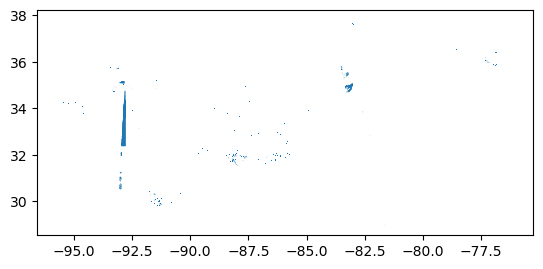

In [74]:
gdf.plot()

<Axes: >

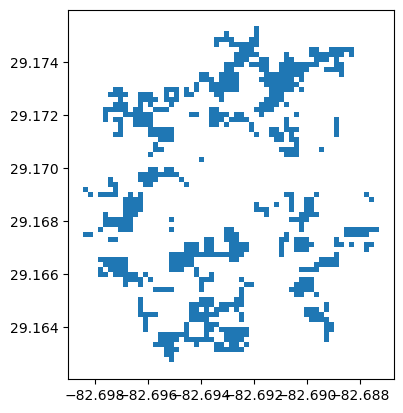

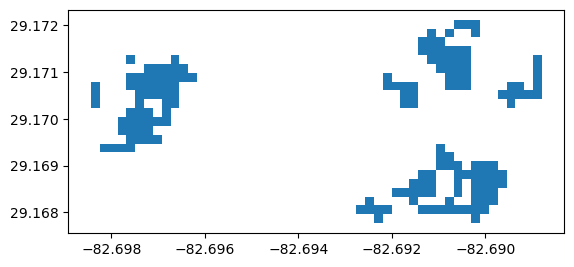

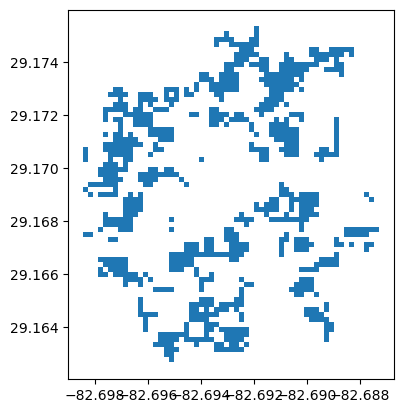

In [75]:
# Assuming your DataFrame is named filtered_polygons_gdf

# Filter rows where 'USDA_IDX' is 'bark_beetle_2017_0'
bark_beetle_2017_0_rows = gdf[gdf['USDA_IDX'] == 'bark_beetle_2017_0']

# Print the filtered DataFrame
bark_beetle_2017_0_rows[0:1].plot()
bark_beetle_2017_0_rows[1:2].plot()
bark_beetle_2017_0_rows.plot()

In [76]:
# Group by 'USDA_IDX' and 'SURV_YEAR' and count the number of rows in each group
duplicate_counts = gdf.groupby(['USDA_IDX', 'SURV_YEAR' ]).size()

# Print the counts of rows with identical 'USDA_IDX' and 'SURV_YEAR'
print("Number of rows with identical USDA_IDX and SURV_YEAR:")
print(duplicate_counts)

# Count the number of unique values in the 'USDA_IDX' column
num_unique_usda_idx = gdf['USDA_IDX'].nunique()

# Print the number of unique USDA_IDX values
print("Number of unique USDA_IDX values:", num_unique_usda_idx)


Number of rows with identical USDA_IDX and SURV_YEAR:
USDA_IDX               SURV_YEAR
bark_beetle_2017_0     2017         2
bark_beetle_2017_1     2017         2
bark_beetle_2017_10    2017         1
bark_beetle_2017_100   2017         1
bark_beetle_2017_1000  2017         2
                                   ..
wind_2019_10606        2019         3
wind_2019_10607        2019         3
wind_2019_10608        2019         2
wind_2019_10609        2019         3
wind_2019_10610        2019         2
Length: 8258, dtype: int64
Number of unique USDA_IDX values: 8258


In [77]:
#gdf.crs = 'epsg:4326'
gdf['area_degrees'] = gdf.geometry.area 
gdf.head(3)

,USDA_IDX,S1_YEAR,S1_TILE,S1CD_IDX,DCA_ID,SURV_YEAR,REG_ID,DAM_TYPE,DAM_TYPE_C,DCA_CD,DA_CD_USDA,PCT_AFFECT,HOST,HOST_CODE,geometry,area_degrees
0,bark_beetle_2019_9080,2020,E084N024T3,9080,bark_beetle,2019,8,Mortality,2,11003,1,Very Severe (>50%),loblolly pine,131.0,"MULTIPOLYGON (((-94.16918 30.44613, -94.16918 ...",0.000029
1,bark_beetle_2019_9081,2020,E084N024T3,9081,bark_beetle,2019,8,Mortality,2,11003,1,Very Severe (>50%),loblolly pine,131.0,"MULTIPOLYGON (((-94.92058 31.15265, -94.92078 ...",0.000040
2,bark_beetle_2019_9082,2020,E084N024T3,9082,bark_beetle,2019,8,Mortality,2,11003,1,Very Severe (>50%),loblolly pine,131.0,"MULTIPOLYGON (((-94.90383 31.16151, -94.90325 ...",0.000044


In [89]:
# Assuming your GeoDataFrame is named gdf

# Calculate the minimum and maximum values of the 'area_degrees' column
min_area_degrees = gdf['area_degrees'].min()
max_area_degrees = gdf['area_degrees'].max()

# Print the results
print("Minimum value of area_degrees:", min_area_degrees)
print("Maximum value of area_degrees:", max_area_degrees)


Minimum value of area_degrees: 3.577358575996664e-08
Maximum value of area_degrees: 0.13804736076017196


In [147]:
gdf = calculate_area(gdf)
gdf.head(4)

/tmp/ipykernel_1675834/2067782447.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  data['area_degrees'] = data.geometry.area


,USDA_IDX,S1_YEAR,S1_TILE,S1CD_IDX,DCA_ID,SURV_YEAR,REG_ID,DAM_TYPE,DAM_TYPE_C,DCA_CD,DA_CD_USDA,PCT_AFFECT,HOST,HOST_CODE,geometry,area_degrees,area_meters,square_km
0,bark_beetle_2019_9080,2020,E084N024T3,9080,bark_beetle,2019,8,Mortality,2,11003,1,Very Severe (>50%),loblolly pine,131.0,"MULTIPOLYGON (((-94.16918 30.44613, -94.16918 ...",0.000029,340416.555708,0.340417
1,bark_beetle_2019_9081,2020,E084N024T3,9081,bark_beetle,2019,8,Mortality,2,11003,1,Very Severe (>50%),loblolly pine,131.0,"MULTIPOLYGON (((-94.92058 31.15265, -94.92078 ...",0.000040,458890.666730,0.458891
2,bark_beetle_2019_9082,2020,E084N024T3,9082,bark_beetle,2019,8,Mortality,2,11003,1,Very Severe (>50%),loblolly pine,131.0,"MULTIPOLYGON (((-94.90383 31.16151, -94.90325 ...",0.000044,510175.284005,0.510175
3,bark_beetle_2019_9083,2020,E084N024T3,9083,bark_beetle,2019,8,Mortality,2,11003,1,Very Severe (>50%),loblolly pine,131.0,"MULTIPOLYGON (((-94.02703 31.88845, -94.02703 ...",0.000016,177365.392539,0.177365


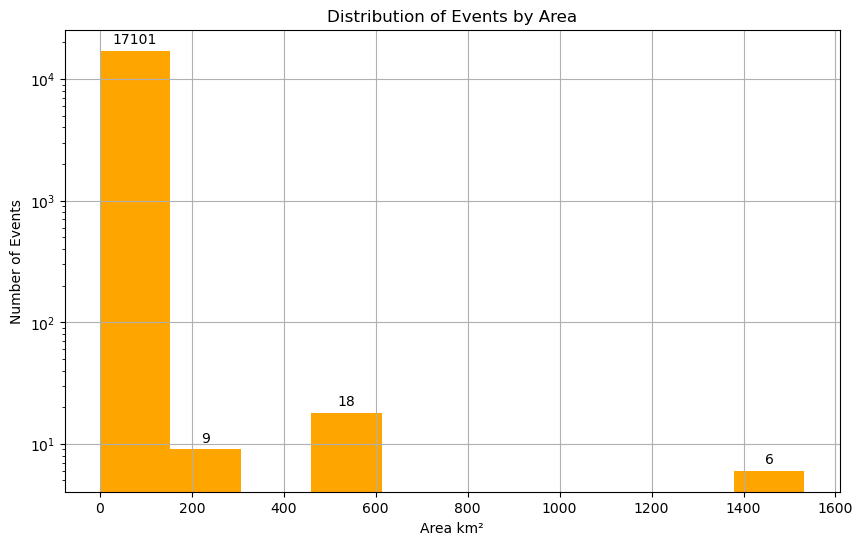

In [148]:
import matplotlib.pyplot as plt

# Assuming your GeoDataFrame is named gdf

# Define a warm orange color
warm_orange = '#FFA500'  # Hexadecimal notation for orange

# Plot the histogram with fewer bins
plt.figure(figsize=(10, 6))
counts, bins, patches = plt.hist(gdf['square_km'], bins=10, color=warm_orange)  # Using 10 bins and warm orange color
plt.xlabel('Area km²')
plt.ylabel('Number of Events')
plt.title('Distribution of Events by Area')
plt.grid(True)
# Add numbers over each bar
for count, patch in zip(counts, patches):
    height = patch.get_height()
    plt.annotate(f'{int(height)}', xy=(patch.get_x() + patch.get_width() / 2, height),
                 xytext=(0, 3), textcoords='offset points',
                 ha='center', va='bottom')

plt.yscale('log')  # Set y-axis scale to logarithmic

plt.show()

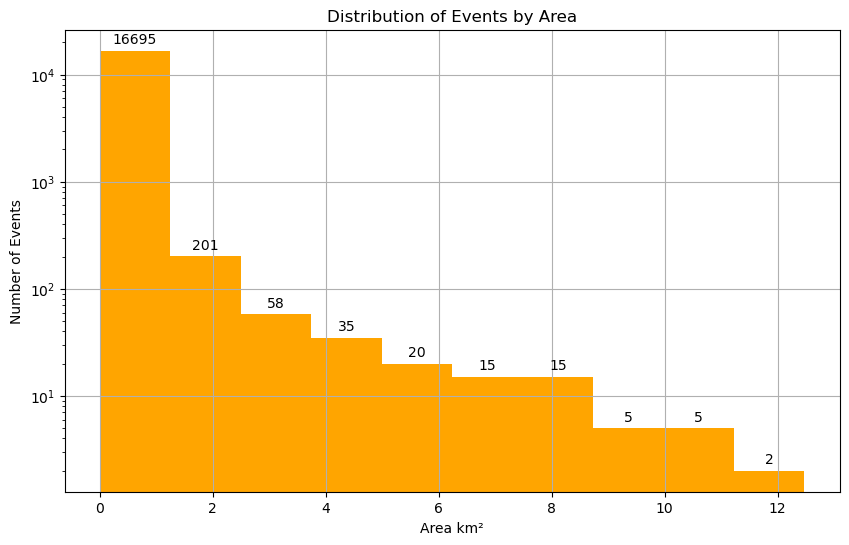

In [149]:
# Filter events with an area less than or equal to 20 square kilometers
gdf_filtered = gdf[gdf['square_km'] <= 15]

import matplotlib.pyplot as plt

# Assuming your GeoDataFrame is named gdf

# Define a warm orange color
warm_orange = '#FFA500'  # Hexadecimal notation for orange

# Plot the histogram with fewer bins
plt.figure(figsize=(10, 6))
counts, bins, patches = plt.hist(gdf_filtered['square_km'], bins=10, color=warm_orange)  # Using 10 bins and warm orange color
plt.xlabel('Area km²')
plt.ylabel('Number of Events')
plt.title('Distribution of Events by Area')
plt.grid(True)
# Add numbers over each bar
for count, patch in zip(counts, patches):
    height = patch.get_height()
    plt.annotate(f'{int(height)}', xy=(patch.get_x() + patch.get_width() / 2, height),
                 xytext=(0, 3), textcoords='offset points',
                 ha='center', va='bottom')

plt.yscale('log')  # Set y-axis scale to logarithmic

plt.show()

<Axes: >

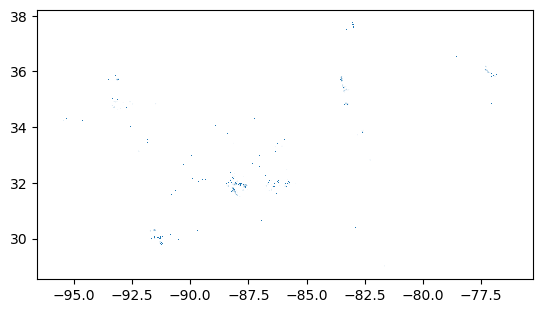

In [136]:
gdf_filtered.plot()